# SpMV Benchmark Analysis (Native vs SME vs SME+SEV)

This notebook analyzes Sparse Matrix-Vector Multiplication (SpMV) benchmark results across multiple configurations.  
The goal is to quantify performance behavior and overheads of encrypted modes (`SME`, `SME+SEV`) relative to `Native`.

## What this notebook does

- Loads per-iteration and full-run benchmark CSV results from multiple output folders.
- Enriches configurations with derived attributes (for example matrix size in MB, randomness, cache-fit indicators).
- Checks iteration-level stability (warmup behavior, plateau shifts, and variability).
- Cleans run-level metrics using IQR-based outlier handling.
- Aggregates metrics per configuration using medians.
- Builds a baseline comparison against `Native` and computes percentage overheads for:
	- runtime (`SpMV_Time`, `IO_Time`)
	- derived throughput (`SpMV_GFLOPS`)
	- hardware counters (cycles, instructions, cache misses, dTLB misses, IPC)
- Visualizes overhead distributions and breakdowns by key dimensions:
	- matrix size (`MB`)
	- randomness
	- core count
	- VM NUMA policy
	- process NUMA policy
	- L3 cache fit
- Applies statistical analysis (including ANOVA/effect size) to identify dominant factors.
- Extracts and inspects high-impact (worst-overhead) configuration subsets.

## Output

The notebook prints intermediate summaries/tables and saves publication-style figures (PDF) under `images/`.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import ttest_rel

sns.set_theme(style="darkgrid", font="DejaVu Serif") #TODO: fix with actual thesis font

matrix_path = "/home/mengelsl/MA-bench-framework/matrices/spmv"

def get_mb(n, randomness):
    r_str = str(randomness).replace('.', '-')
    f_path = os.path.join(matrix_path, f"{r_str}_N{int(n)}.bin")
    try:
        return round(os.path.getsize(f_path) / (1024**2))
    except: return None

main_folder = {
    "Native": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/native/",
    "SME": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme/",
    "SME+SEV": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev/",
    "Native_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/native_interleave/",
    "SME_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme_interleave/",
    "SME+SEV_interleave": "/home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev_interleave/",
}

# Data Validity per Iter

In [334]:
config_cols_iter = ['Mode', 'MB', 'Randomness', 'Cores', 'VM_NUMA', 'Process_NUMA']
iter_list = []

for label, base_path in main_folder.items():
    extra_path = os.path.join(base_path, "extra")
    
    for folder in os.listdir(extra_path):
        csv_p = os.path.join(extra_path, folder, "iter.csv")
        match = re.search(r'(\d-\d)_N(\d+)_c(\d+)_(\w+)', folder)
        
        if os.path.exists(csv_p) and match:
            it_df = pd.read_csv(csv_p)
            it_df['Mode'] = label.replace("_interleave", "")
            it_df['Randomness'] = float(match.group(1).replace('-', '.'))
            it_df['N'] = int(match.group(2))
            it_df['Cores'] = int(match.group(3))
            it_df['Process_NUMA'] = match.group(4)
            it_df['VM_NUMA'] = "interleave" if "interleave" in label else "strict"
            it_df['MB'] = get_mb(it_df['N'].iloc[0], it_df['Randomness'].iloc[0])
            iter_list.append(it_df)


# This takes ~3 minutes
df_iters = pd.concat(iter_list, ignore_index=True).groupby(config_cols_iter + ['Iter']).median().reset_index()
print(f"Loaded {len(df_iters)*15} individual iterations. Median computed for {len(df_iters)} data points.")

Loaded 408661650 individual iterations. Median computed for 27244110 data points.


In [371]:
def get_config_stability(group, window_size=15, threshold_pct=5.0, warmup_tol=0.05, stable_window=5):
    times = group['Time'].values
    n = len(times)

    if n < window_size:
        return pd.Series({
            "Warmup_Iters": np.nan,
            "Warmup_Pct": np.nan,
            "P2P_Shift_Pct": np.nan,
            "Is_Stable": True,
            "Too_Small": True
        })

    ref = np.median(times)
    rel_err = np.abs((times - ref) / ref)

    # --- find first stable region
    warmup_end = None
    for i in range(0, n - stable_window + 1):
        if np.all(rel_err[i:i+stable_window] <= warmup_tol):
            warmup_end = i
            break

    if warmup_end is None:
        return pd.Series({
            "Warmup_Iters": np.nan,
            "Warmup_Pct": np.nan,
            "P2P_Shift_Pct": np.nan,
            "Is_Stable": False,
            "Too_Small": False
        })

    # ---  cut warmup
    stable_times = times[warmup_end:]

    if len(stable_times) < window_size:
        return pd.Series({
            "Warmup_Iters": warmup_end,
            "Warmup_Pct": warmup_end / n * 100,
            "P2P_Shift_Pct": np.nan,
            "Is_Stable": True,
            "Too_Small": True
        })

    # --- stability after warmup
    rolling = pd.Series(stable_times).rolling(window=window_size, center=True).mean()
    valid = rolling.dropna()

    global_med = np.median(stable_times)

    p2p_shift = (np.percentile(valid, 98) - np.percentile(valid, 2)) / global_med * 100

    return pd.Series({
        "Warmup_Iters": int(warmup_end),
        "Warmup_Pct": warmup_end / n * 100,
        "P2P_Shift_Pct": p2p_shift,
        "Is_Stable": p2p_shift < threshold_pct,
        "Too_Small": False
    })


stability_report = df_iters.groupby(config_cols_iter).apply(get_config_stability, include_groups=False).reset_index()

In [377]:
stability_report["Too_Small"].value_counts()

Too_Small
False    468
True      12
Name: count, dtype: int64

In [378]:
stability_report["Warmup_Pct"].describe()

count    468.000000
mean       0.087119
std        0.202579
min        0.000000
25%        0.000000
50%        0.006813
75%        0.075157
max        1.204819
Name: Warmup_Pct, dtype: float64

In [379]:
#before looking at the stability results, lets look at those with too few iterations 
few_iter = df_iters.merge( stability_report[stability_report["Too_Small"]], on=config_cols_iter, how='inner')

def get_stats(group):
    y = group['Time'].values
    x = np.arange(len(y))
    
    slope = np.polyfit(x, y, 1)[0]
    slope_pct = (slope / np.mean(y)) * 100
    
    cv = (np.std(y) / np.mean(y)) * 100
    range_pct = ((np.max(y) - np.min(y)) / np.mean(y)) * 100
    
    return pd.Series({
        "Slope_Pct": slope_pct,
        "CV_Pct": cv,
        "Range_Pct": range_pct
    })

few_iter_stats = few_iter.groupby(config_cols_iter).apply(get_stats, include_groups=False).reset_index()
print(f"Max slope: {few_iter_stats['Slope_Pct'].abs().max():.4f}%")
print(f"Max CV: {few_iter_stats['CV_Pct'].abs().max():.4f}%")
print(f"Max Range: {few_iter_stats['Range_Pct'].abs().max():.4f}%")
# Those configs were already set to Is_Stable = True, nothing to change there

Max slope: 0.0126%
Max CV: 0.0869%
Max Range: 0.2012%


In [380]:
stability_report["Is_Stable"].value_counts()

Is_Stable
True     471
False      9
Name: count, dtype: int64

In [381]:
#downsampling for plotting
def downsample(df, group_cols, n_points=200):
    def process_config(config_group):

        unique_iters = np.sort(config_group['Iter'].unique())

        if len(unique_iters) <= n_points:
            target_iters = unique_iters
        else:
            idx = np.linspace(0, len(unique_iters) - 1, n_points).astype(int)
            target_iters = unique_iters[idx]

        # Select the sampled iterations
        sampled = config_group[config_group['Iter'].isin(target_iters)].copy()

        # Keep one row per iteration (already median-aggregated upstream)
        sampled = sampled.sort_values('Iter')

        # Normalize iteration index
        sampled["IterNorm"] = np.linspace(0, 1, len(sampled))

        return sampled

    return df.groupby(group_cols, group_keys=False).apply(process_config).reset_index(drop=True)

df_iters_small = downsample(df_iters, group_cols=config_cols_iter, n_points=200)
print(f"Downsampled to {len(df_iters_small)} rows")

Downsampled to 85548 rows


/tmp/ipykernel_1298168/1610360081.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby(group_cols, group_keys=False).apply(process_config).reset_index(drop=True)


Mode
SME        4
SME+SEV    3
Native     2
Name: count, dtype: int64 MB
70    9
Name: count, dtype: int64 Cores
1    9
Name: count, dtype: int64 Randomness
1.0    9
Name: count, dtype: int64
Average Max Plateau Shift Impact (%): 9.909612520555024


/tmp/ipykernel_1298168/2996215110.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  comparison_df['Is_Plateau_Config'] = comparison_df['Is_Plateau_Config'].fillna(False)


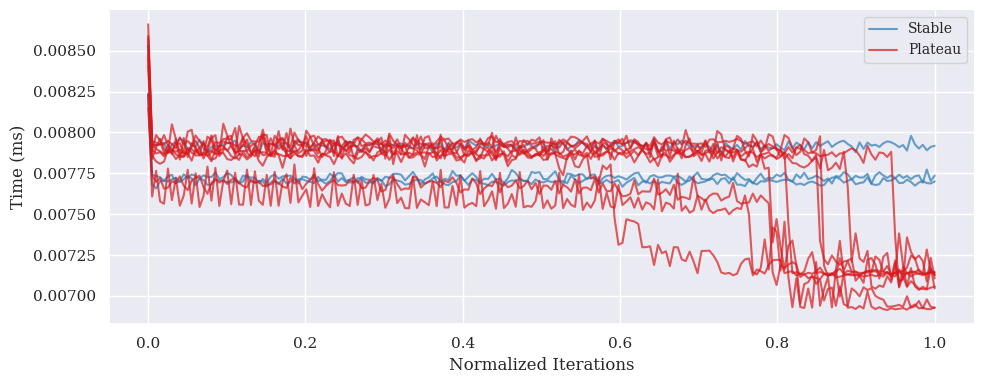

In [382]:
not_straight_large = stability_report[(~stability_report["Is_Stable"]) & (~stability_report["Too_Small"])]
print(not_straight_large["Mode"].value_counts(), not_straight_large["MB"].value_counts(), not_straight_large["Cores"].value_counts(), not_straight_large["Randomness"].value_counts())
print("Average Max Plateau Shift Impact (%):", not_straight_large["P2P_Shift_Pct"].mean())

# "Problematic" Configuration
comparison_df = df_iters_small[ (df_iters_small['MB'] == 70) & (df_iters_small['Cores'] == 1) & (df_iters_small['Randomness'] == 1) ].copy()

# Identify shifted keys in the comparison DataFrame to visualize them with another color
shifted_keys = not_straight_large.merge( comparison_df[config_cols_iter], on=config_cols_iter)[config_cols_iter].drop_duplicates()
comparison_df = comparison_df.merge( shifted_keys.assign(Is_Plateau_Config=True), on=config_cols_iter, how='left')
comparison_df['Is_Plateau_Config'] = comparison_df['Is_Plateau_Config'].fillna(False)

# Define the Display Category
comparison_df['Display_Group'] = np.where(
    comparison_df['Is_Plateau_Config'], 
    "Plateau",
    "Stable", 
)

# 4. Unique ID for individual lines
comparison_df['Config_Line_ID'] = comparison_df[config_cols_iter].astype(str).agg('-'.join, axis=1)

plt.figure(figsize=(10, 4)) 

# 2. Use lineplot (Axes-level) instead of relplot
sns.lineplot(
    data=comparison_df,
    x="IterNorm",
    y="Time",
    hue="Display_Group",
    units="Config_Line_ID",
    estimator=None, 
    palette={
        "Plateau": "#d7191c",
        "Stable": "#2c7bb6",    
    },
    alpha=0.7,      
)

# 3. Compact Legend inside the plot
# 'upper left' or 'lower right' usually works best depending on your data curve
plt.legend(title=None, frameon=True, fontsize='small')

# 4. Clean labels
plt.xlabel("Normalized Iterations")
plt.ylabel("Time (ms)")

# 5. Remove top/right spines for a modern look
sns.despine()

plt.tight_layout()
plt.savefig("images/SpMV_Stability_Comparison.pdf", bbox_inches='tight')

#Plateau shift happens between about 60 and 90% of iterations

In [ ]:
# See visually that most configs are stable

for rnd in sorted(df_iters_small["Randomness"].dropna().unique()):
    for vm in sorted(df_iters_small["VM_NUMA"].dropna().unique()):
        for proc in sorted(df_iters_small["Process_NUMA"].dropna().unique()):
            sub = df_iters_small[
                (df_iters_small["Randomness"] == rnd) &
                (df_iters_small["VM_NUMA"] == vm) &
                (df_iters_small["Process_NUMA"] == proc)
            ].copy()

            if sub.empty:
                continue

            sub = sub.sort_values("IterNorm")

            g = sns.relplot(
                data=sub,
                kind="line",
                x="IterNorm",
                y="Time",
                hue="Mode",
                row="MB",
                col="Cores",
                errorbar=None,
                sort=False,
                palette="viridis",
                facet_kws={"sharey": False, "sharex": True},
                alpha=0.7,
                height=2.3,
                aspect=1.1
            )

            g.set_axis_labels("Normalized iteration progress", "Time (ms)")
            g.set_titles("MB: {row_name} | Cores: {col_name}")
            g.set(xlim=(0, 1), xticks=np.linspace(0, 1, 5))
            g.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
            g.fig.suptitle(
                f"Time over Iter | Randomness={rnd} | VM_NUMA={vm} | Process_NUMA={proc}",
                y=1.02
            )
            g.tight_layout()
            plt.show()

# Aggregated results analysis

## Data preparation

In [2]:
results_list = []

for label, path in main_folder.items():
    f_path = os.path.join(path, "results.csv")
    print(f"Checking for {label} at {f_path}...")
    if os.path.exists(f_path):
        df = pd.read_csv(f_path)
        print(f"Loaded {len(df)} rows for {label}.")
        df["Mode"] = label.split("_interleave")[0]
        df["VM_NUMA"] = "interleave" if "interleave" in label else "strict"
        results_list.append(df)

df_raw = pd.concat(results_list, ignore_index=True)
df_raw.rename(columns={"Process_NUMA_Policy": "Process_NUMA"}, inplace=True)

Checking for Native at /home/mengelsl/MA-bench-framework/outputs/SpMV_final/native/results.csv...
Loaded 1200 rows for Native.
Checking for SME at /home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme/results.csv...
Loaded 1200 rows for SME.
Checking for SME+SEV at /home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev/results.csv...
Loaded 1200 rows for SME+SEV.
Checking for Native_interleave at /home/mengelsl/MA-bench-framework/outputs/SpMV_final/native_interleave/results.csv...
Loaded 1200 rows for Native_interleave.
Checking for SME_interleave at /home/mengelsl/MA-bench-framework/outputs/SpMV_final/sme_interleave/results.csv...
Loaded 1200 rows for SME_interleave.
Checking for SME+SEV_interleave at /home/mengelsl/MA-bench-framework/outputs/SpMV_final/sev_interleave/results.csv...
Loaded 1200 rows for SME+SEV_interleave.


In [3]:
# Iterations is in here, because it does not change per config and this simply keeps the column
config_cols_raw = ["Mode", "Matrix", "Cores", "Process_NUMA", "VM_NUMA", "Iterations"]
metric_cols_raw = [ "IO_Time", "SpMV_Time", "Perf_Cycles", "Perf_Instructions", "Perf_CacheMisses", "Perf_dTLBMisses" ]

config_drop_counts = []

def iqr_mark_outliers(group):
    group = group.copy()
    group_drops = 0

    for col in metric_cols_raw:
        if col not in group.columns:
            continue
        
        data = pd.to_numeric(group[col], errors="coerce")
        valid = data.dropna()
        
        if valid.empty:
            continue
        
        q1, q3 = valid.quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        
        mask = (data >= lower) & (data <= upper)
        
        group_drops += (~mask & data.notna()).sum()
        
        # Mark outliers as NaN
        group.loc[~mask, col] = np.nan

    config_drop_counts.append(group_drops)
    return group

df_clean = df_raw.groupby(config_cols_raw).apply(iqr_mark_outliers, include_groups=False).reset_index()

total_points_removed = np.sum(config_drop_counts)

print(f"Total metric data points: {len(df_raw) * len(metric_cols_raw)}")
print(f"Total data points removed: {total_points_removed}")
print(f"Data points removed (%): {total_points_removed / (len(df_raw) * len(metric_cols_raw)) * 100:.2f}%")

Total metric data points: 43200
Total data points removed: 2193
Data points removed (%): 5.08%


<Figure size 1600x400 with 0 Axes>

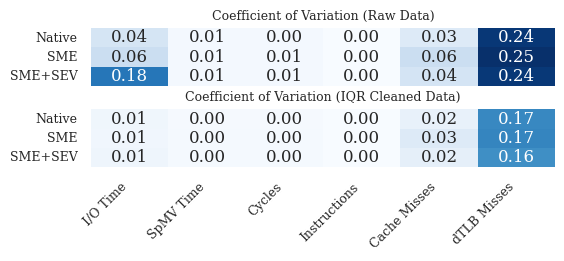

In [4]:
def compute_cv_per_mode(df, config_cols_raw, metrics):
    stats = (
        df
        .groupby(config_cols_raw)[metrics]
        .agg(["mean", "std"])
    )
    
    cv = stats.xs("std", level=1, axis=1) / stats.xs("mean", level=1, axis=1)

    # Aggregate over Mode (first level)
    cv_mode = cv.groupby(level=0).mean()

    cv_mode.fillna(0, inplace=True)
    
    return cv_mode

cv_raw_mode = compute_cv_per_mode(df_raw, config_cols_raw, metric_cols_raw)
cv_clean_mode = compute_cv_per_mode(df_clean, config_cols_raw, metric_cols_raw)

rename_dict = {
	"IO_Time": "I/O Time",
	"SpMV_Time": "SpMV Time",
	"Perf_Cycles": "Cycles",
    "Perf_Instructions": "Instructions",
    "Perf_CacheMisses": "Cache Misses",
    "Perf_dTLBMisses": "dTLB Misses",
}

plt.figure(figsize=(16, 4))
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True , gridspec_kw={'right': 0.85})
v_max = max(cv_raw_mode.max().max(), cv_clean_mode.max().max())

kwargs = dict(
    cmap="Blues",
    annot=True,
    fmt=".2f",
    cbar=False,
    vmin=0,
    vmax=v_max,
)

sns.heatmap(cv_raw_mode.rename(columns=rename_dict), ax=ax1, **kwargs)
ax1.set_title("Coefficient of Variation (Raw Data)", fontsize=9)
ax1.set_ylabel("")
ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=9)

sns.heatmap(cv_clean_mode.rename(columns=rename_dict), ax=ax2, **kwargs)
ax2.set_title("Coefficient of Variation (IQR Cleaned Data)", fontsize=9)
ax2.set_ylabel("")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax2.set_yticklabels(ax2.get_yticklabels(), fontsize=9)

plt.subplots_adjust(hspace=0.4, top=0.4)
plt.savefig("images/cv_heatmap_raw_vs_clean.pdf", bbox_inches='tight')

In [5]:
# fully cleaned data grouped by config, median of runs
df = df_clean.groupby(config_cols_raw)[metric_cols_raw].median().reset_index()

df['N'] = df['Matrix'].str.extract(r'N(\d+)').astype(int)
r = df['Matrix'].str.extract(r'(\d)-(\d)')
df['Randomness'] = (r[0] + "." + r[1]).astype(float)
df['MB'] = df.apply(lambda row: get_mb(row['N'], row['Randomness']), axis=1).astype('Int64')
k = 30  # nnz per row
#2 operations per non-zero element (multiply and add)
# TODO: the cpp gflops were calculated wrong, delete everything regarding that
df['SpMV_GFLOPS'] = ( 2 * k * df['N']) / ( (df['SpMV_Time'] / df['Iterations']) * 1e9)
#based on 32MB L3 per 8 cores
L3_size = {
    1: 32,
    8: 32,
    24: 96,
    48: 192,
}
df['L3_fit'] = df['MB'] <= df['Cores'].map(L3_size)
df["Perf_IPC"] = df['Perf_Instructions'] / df['Perf_Cycles']
df.drop(columns=["N","Matrix"], inplace=True)

config_cols = ["Mode", "MB", "Randomness", "Cores", "Process_NUMA", "VM_NUMA", "L3_fit"]
metric_cols = metric_cols_raw + ["SpMV_GFLOPS", "Perf_IPC"]

df.head()

,Mode,Cores,Process_NUMA,VM_NUMA,Iterations,IO_Time,SpMV_Time,Perf_Cycles,Perf_Instructions,Perf_CacheMisses,Perf_dTLBMisses,Randomness,MB,SpMV_GFLOPS,L3_fit,Perf_IPC
0,Native,1,interleave,interleave,369,0.081600,9.948239,3.613565e+10,1.993093e+11,3298979.0,364995.0,0.0,500,3.205531,False,5.515586
1,Native,1,interleave,strict,369,0.082036,9.993071,3.630054e+10,1.993093e+11,3276049.0,395074.5,0.0,500,3.191150,False,5.490532
2,Native,1,membind,interleave,369,0.081796,9.945920,3.612669e+10,1.993093e+11,3276159.0,345223.0,0.0,500,3.206279,False,5.516955
3,Native,1,membind,strict,369,0.081642,9.991050,3.630536e+10,1.993093e+11,3250803.0,344848.0,0.0,500,3.191796,False,5.489804
4,Native,8,interleave,interleave,713,0.081595,10.267954,2.962630e+11,3.852660e+11,16812143.0,16328.0,0.0,500,6.001026,False,1.300419


In [6]:
from scipy.stats import linregress
res_gflops = linregress(df['Perf_IPC']*df["Cores"], df['SpMV_GFLOPS'])
res_time = linregress(df['Perf_IPC']*df["Cores"], df['SpMV_Time'])
    
print(f'Time: R² = {res_time.rvalue**2:.3f}, GFLOPS: R² = {res_gflops.rvalue**2:.3f}')

Time: R² = 0.002, GFLOPS: R² = 1.000


In [7]:
merge_cols = [c for c in config_cols if c != "Mode"]

df_native = df[df['Mode'] == 'Native'].copy()
df_other = df[df['Mode'] != 'Native'].copy()

df_merged = df_other.merge(
    df_native,
    on=merge_cols,
    suffixes=('', '_native')
)
result = df_merged.copy()

for m in metric_cols:
    native_col = f"{m}_native"

    result[f"{m}_pct"] = np.where(
        df_merged[native_col] != 0,
        (df_merged[m] - df_merged[native_col]) / df_merged[native_col] * 100,
        np.nan
    )

overhead_df = result

## Absolute GFLOPS baseline

→ MB:
Mode  Native  SME  SME+SEV
MB                        
10      40.0 39.4     39.4
70      42.8 42.4     42.0
150     36.9 36.6     36.1
500     14.6 14.3     14.2
3000     7.9  7.8      7.8
------------------------------------------------------------
→ Cores:
Mode   Native  SME  SME+SEV
Cores                      
1         2.4  2.3      2.3
8        10.0 10.0     10.0
24       34.9 34.5     34.4
48       66.3 65.5     64.9
------------------------------------------------------------
→ Randomness:
Mode        Native  SME  SME+SEV
Randomness                      
0.0           34.6 34.2     34.0
1.0           22.2 21.9     21.8
------------------------------------------------------------
→ VM NUMA:
Mode        Native  SME  SME+SEV
VM_NUMA                         
strict        27.2 26.6     26.7
interleave    29.7 29.6     29.1
------------------------------------------------------------
→ Process NUMA:
Mode          Native  SME  SME+SEV
Process_NUMA                      
membind  

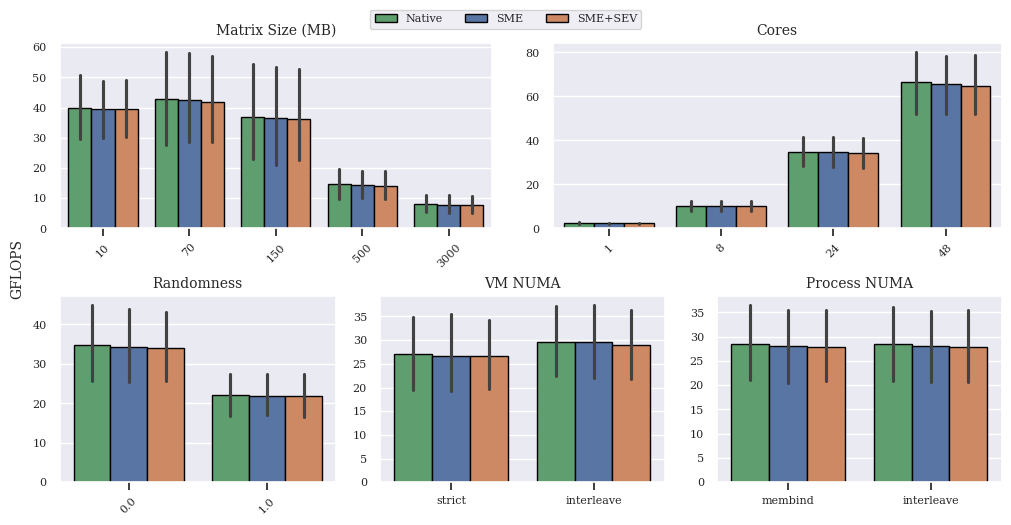

In [8]:
def plot_metric_by_dimensions(
    input_df,
    metric,
    y_axis_name,
    top=False,
    figname=None,
    palette=None,
    legend=True,
    top_metrics=("MB", "Cores"),
    bottom_metrics=("Randomness", "VM_NUMA", "Process_NUMA")
):
    dim_orders = {
        "VM_NUMA": ["strict", "interleave"],
        "Process_NUMA": ["membind", "interleave"],
    }

    has_bottom = bool(bottom_metrics)

    if has_bottom:
        fig = plt.figure(figsize=(10, 5), constrained_layout=True)
        gs = fig.add_gridspec(2, 6, height_ratios=[1, 1])
        axes = {
            top_metrics[0]: fig.add_subplot(gs[0, 0:3]),
            top_metrics[1]: fig.add_subplot(gs[0, 3:6]),
            bottom_metrics[0]: fig.add_subplot(gs[1, 0:2]),
            bottom_metrics[1]: fig.add_subplot(gs[1, 2:4]),
            bottom_metrics[2]: fig.add_subplot(gs[1, 4:6]),
        }
    else:
        fig = plt.figure(figsize=(10, 3), constrained_layout=True)
        gs = fig.add_gridspec(1, 6)
        axes = {
            top_metrics[0]: fig.add_subplot(gs[0, 0:3]),
            top_metrics[1]: fig.add_subplot(gs[0, 3:6]),
        }

    fig.supylabel(y_axis_name, fontsize=10)

    title_map = {
        "MB": "Matrix Size (MB)",
        "Cores": "Cores",
        "Randomness": "Randomness",
        "VM_NUMA": "VM NUMA",
        "Process_NUMA": "Process NUMA",
    }

    ordered_dims = list(top_metrics) + (list(bottom_metrics) if has_bottom else [])
    legend_handles, legend_labels = None, None

    for a in ordered_dims:
        ax = axes[a]
        sns.barplot(
            data=input_df,
            x=a,
            y=metric,
            hue="Mode",
            order=dim_orders.get(a, None),
            errorbar=("ci", 95),
            edgecolor="black",
            ax=ax,
            palette=palette
        )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        if ax.get_legend() is not None:
            ax.get_legend().remove()

        ax.set_title(title_map.get(a, a.replace("_", " ")), fontsize=10)
        ax.set_ylabel("")
        ax.set_xlabel("")
        rotation = 0 if a in ["VM_NUMA", "Process_NUMA"] else 45
        ax.tick_params(axis="x", rotation=rotation, labelsize=8)
        ax.tick_params(axis="y", labelsize=8)

        if top:
            ax.xaxis.set_ticks_position("top")
            ax.xaxis.set_label_position("top")
        else:
            ax.xaxis.set_ticks_position("bottom")
            ax.xaxis.set_label_position("bottom")

    if legend and legend_handles is not None:
        fig.legend(
            legend_handles,
            legend_labels,
            loc="upper center",
            ncol=3,
            bbox_to_anchor=(0.5, 1.03),
            fontsize=8
        )

    if figname:
        fig.savefig(f"images/{figname}", bbox_inches="tight")

    for dim in ordered_dims:
        print(f"→ {dim.replace('_', ' ')}:")
        summary = (
            input_df.groupby([dim, "Mode"])[metric]
            .mean()
            .round(2)
            .reset_index()
        )
        summary_pivot = summary.pivot(index=dim, columns="Mode", values=metric)
        if dim in dim_orders:
            summary_pivot = summary_pivot.reindex(dim_orders[dim])

        print(summary_pivot.to_string(float_format="{:.1f}".format))
        print("-" * 60)


base = sns.color_palette("deep", 3)
palette = {
    "Native": base[2],
    "SME": base[0],
    "SME+SEV": base[1]
}

plot_metric_by_dimensions(
    df,
    "SpMV_GFLOPS",
    "GFLOPS",
    top=False,
    figname="absolute_gflops_per_dim.pdf",
    palette=palette,
    legend=True
)

In [9]:
# Average deviation between Process_NUMA configs (interleave vs membind) for SpMV_GFLOPS
pair_cols = ["Mode", "MB", "Randomness", "Cores", "VM_NUMA"]

base_proc, compare_proc = "membind", "interleave"

proc_cmp = (
	df.pivot_table(
		index=pair_cols,
		columns="Process_NUMA",
		values="SpMV_GFLOPS",
		aggfunc="mean"
	)
	.dropna(subset=[base_proc, compare_proc])
	.reset_index()
)

proc_cmp["Deviation_pct"] = (
	(proc_cmp[compare_proc] - proc_cmp[base_proc]) / proc_cmp[base_proc] * 100
)
proc_cmp["Abs_Deviation_pct"] = proc_cmp["Deviation_pct"].abs()

print(f"Average deviation ({compare_proc} vs {base_proc}): {proc_cmp['Deviation_pct'].median():.4f}%")
print(f"Average absolute deviation: {proc_cmp['Abs_Deviation_pct'].median():.4f}%")

print("\nBy mode:")
print(
	proc_cmp.groupby("Mode")[["Deviation_pct", "Abs_Deviation_pct"]]
	.median()
	.round(3)
)

Average deviation (interleave vs membind): -0.0146%
Average absolute deviation: 0.0897%

By mode:
Process_NUMA  Deviation_pct  Abs_Deviation_pct
Mode                                          
Native               -0.022              0.065
SME                  -0.003              0.083
SME+SEV              -0.016              0.113


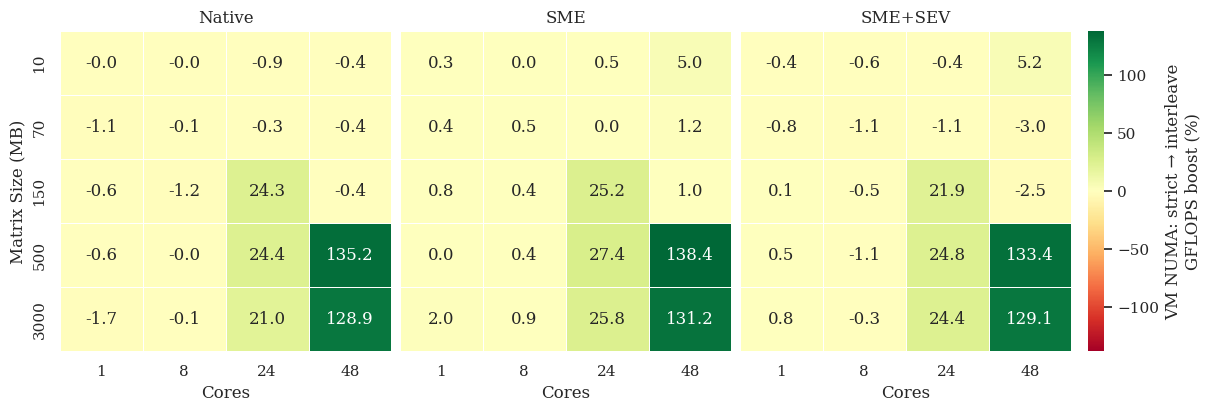

In [10]:
# VM_NUMA boost: interleave vs strict
heat_df = (
	df.pivot_table(
		index=["Mode", "MB", "Cores", "Randomness", "Process_NUMA"],
		columns="VM_NUMA",
		values="SpMV_GFLOPS",
		aggfunc="mean"
	)
	.dropna(subset=["interleave", "strict"])
	.reset_index()
)

heat_df["Boost_pct"] = (heat_df["interleave"] - heat_df["strict"]) / heat_df["strict"] * 100

# Per-mode cell values (MB, Cores, Mode)
mode_cell = (
	heat_df.groupby(["MB", "Cores", "Mode"], as_index=False)["Boost_pct"]
	.mean()
)

mode_order = ["Native", "SME", "SME+SEV"]
modes = [m for m in mode_order if m in mode_cell["Mode"].unique()]

vabs = mode_cell["Boost_pct"].abs().max()
fig, axes = plt.subplots(1, len(modes), figsize=(12, 4), constrained_layout=True, sharey=True)

if len(modes) == 1:
	axes = [axes]

for i, mode in enumerate(modes):
	p_mode = (
		mode_cell[mode_cell["Mode"] == mode]
		.pivot(index="MB", columns="Cores", values="Boost_pct")
		.sort_index()
	)
	p_mode = p_mode.reindex(sorted(p_mode.columns), axis=1)

	sns.heatmap(
		p_mode,
		ax=axes[i],
		cmap="RdYlGn",
		center=0,
		vmin=-vabs,
		vmax=vabs,
		annot=True,
		fmt=".1f",
		linewidths=0.4,
		linecolor="white",
		cbar=(i == len(modes) - 1),
		cbar_kws={"label": "VM NUMA: strict → interleave\nGFLOPS boost (%)"} if i == len(modes) - 1 else None
	)

	axes[i].set_title(mode)
	axes[i].set_xlabel("Cores")
	if i == 0:
		axes[i].set_ylabel("Matrix Size (MB)")
	else:
		axes[i].set_ylabel("")
		axes[i].tick_params(axis="y", left=False, labelleft=False)

fig.savefig("images/vm_numa_boost_heatmap_by_mode.pdf", bbox_inches="tight")
plt.show()

## GFLOPS overhead overview

In [11]:
overhead_df.groupby("Mode")["SpMV_GFLOPS_pct"].aggregate(['mean', 'median'])

,mean,median
Mode,,
SME,-1.613351,-0.435216
SME+SEV,-1.881618,-1.076064


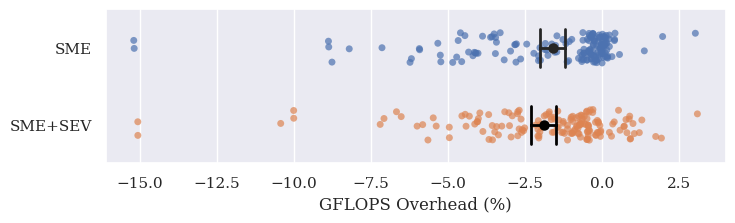

In [164]:
plt.figure(figsize=(8, 2))
sns.pointplot(
    data=overhead_df, 
    x="SpMV_GFLOPS_pct", 
    y="Mode", 
    hue="Mode",
    linestyle=None,
    markersize=6,        
    linewidth=2,             
    capsize=0.5,
    palette="dark:black",
    legend=False,
    zorder=2
)

sns.stripplot(
    data=overhead_df, 
    x="SpMV_GFLOPS_pct", 
    y="Mode", 
    hue="Mode",
    jitter=0.2,
    alpha=0.7,
    zorder=1
)

plt.xlabel("GFLOPS Overhead (%)")
plt.ylabel("")
plt.savefig("images/GFLOPS_Overhead_Distribution.pdf", bbox_inches='tight')

In [13]:
count_SME_low_impact = ((overhead_df["Mode"] == "SME") & (overhead_df["SpMV_GFLOPS_pct"] > -1)).sum()
total_SME = (overhead_df["Mode"] == "SME").sum()
count_SEV_low_impact = ((overhead_df["Mode"] == "SME+SEV") & (overhead_df["SpMV_GFLOPS_pct"] > -1)).sum()
total_SEV = (overhead_df["Mode"] == "SME+SEV").sum()
print(f"SME low impact (> -1%): {count_SME_low_impact} / {total_SME} = {count_SME_low_impact / total_SME}")
print(f"SME+SEV low impact (> -1%): {count_SEV_low_impact} / {total_SEV} = {count_SEV_low_impact / total_SEV}")

SME low impact (> -1%): 99 / 160 = 0.61875
SME+SEV low impact (> -1%): 77 / 160 = 0.48125


In [14]:
count = (overhead_df["SpMV_GFLOPS_pct"] > 1).sum()
total = overhead_df["SpMV_GFLOPS_pct"].count()
count2 = (overhead_df["SpMV_GFLOPS_pct"] > 0).sum()
total2 = overhead_df["SpMV_GFLOPS_pct"].count()

print(f"Encrypted outperforms native by > 1%: {count} / {total} = {count / total}")
print(f"Encrypted outperforms native by > 0%: {count2} / {total2} = {count2 / total2}")

Encrypted outperforms native by > 1%: 9 / 320 = 0.028125
Encrypted outperforms native by > 0%: 55 / 320 = 0.171875


## ANOVA

In [15]:
targets = [ "SpMV_GFLOPS_pct" ]

def full_anova(df, target):
    d = df.dropna(subset=[ target, "MB", "Cores", "Randomness", "Process_NUMA", "VM_NUMA"]).copy()

	# C for categorical, handled internally by statsmodels
    formula = f"{target} ~ MB + C(Randomness) + Cores + C(Process_NUMA) + C(VM_NUMA)"

    model = ols(formula, data=d).fit()

    #https://md.psych.bio.uni-goettingen.de/mv/unit/lm_cat/lm_cat_unbal_ss_explained.html
    table = sm.stats.anova_lm(model, typ=3)

    table["eta_sq"] = table["sum_sq"] / table["sum_sq"].sum()

    return table.sort_values("eta_sq", ascending=False)

def run(df):
    df["MB"] = pd.to_numeric(df["MB"], errors="coerce").astype("float64")
    df["Cores"] = pd.to_numeric(df["Cores"], errors="coerce").astype("float64")
    df["Randomness"] = pd.to_numeric(df["Randomness"], errors="coerce").astype("float64")

    print("Rows:", len(df))

    results = {}

    for t in targets:

        anova_sme = full_anova(df[df["Mode"] == "SME"].copy(), t)
        anova_sev = full_anova(df[df["Mode"] == "SME+SEV"].copy(), t)
        results[t] = anova_sme
        results[t] = anova_sev

        print("\n" + "="*60)
        print("TARGET:", t, "MODE: SME")
        print("="*60)
        print(anova_sme)
        print("\n" + "="*60)
        print("TARGET:", t, "MODE: SME+SEV")
        print("="*60)
        print(anova_sev)

    return results


results = run(overhead_df)

Rows: 320

TARGET: SpMV_GFLOPS_pct MODE: SME
                     sum_sq     df          F    PR(>F)    eta_sq
Residual         877.132548  154.0        NaN       NaN  0.793543
C(VM_NUMA)        86.968057    1.0  15.269164  0.000139  0.078680
MB                79.699366    1.0  13.992985  0.000258  0.072104
C(Randomness)     57.931618    1.0  10.171176  0.001728  0.052411
Cores              3.140076    1.0   0.551310  0.458914  0.002841
C(Process_NUMA)    0.451741    1.0   0.079313  0.778608  0.000409
Intercept          0.014394    1.0   0.002527  0.959971  0.000013

TARGET: SpMV_GFLOPS_pct MODE: SME+SEV
                     sum_sq     df          F    PR(>F)    eta_sq
Residual         987.123490  154.0        NaN       NaN  0.871063
C(Randomness)     73.549301    1.0  11.474342  0.000896  0.064902
MB                60.015953    1.0   9.363020  0.002612  0.052960
Intercept         10.373544    1.0   1.618365  0.205238  0.009154
Cores              1.501463    1.0   0.234242  0.629084  0

## System parameter effects

Plotted mean GFLOPS overhead (%) per Randomness/Cores/Mode:
 Randomness  Cores    Mode  SpMV_GFLOPS_pct
        0.0      1     SME             -0.3
        0.0      1 SME+SEV             -0.7
        0.0      8     SME             -0.4
        0.0      8 SME+SEV              0.1
        0.0     24     SME             -1.4
        0.0     24 SME+SEV             -1.8
        0.0     48     SME             -1.9
        0.0     48 SME+SEV             -2.4
        1.0      1     SME             -5.4
        1.0      1 SME+SEV             -5.6
        1.0      8     SME             -0.5
        1.0      8 SME+SEV             -0.5
        1.0     24     SME             -1.7
        1.0     24 SME+SEV             -2.1
        1.0     48     SME             -1.3
        1.0     48 SME+SEV             -2.1


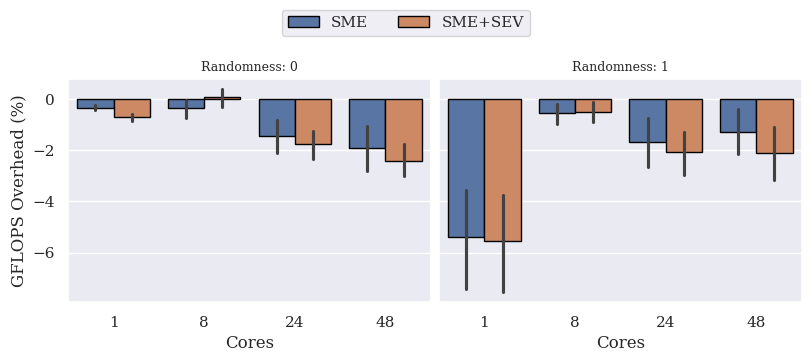

In [35]:
plot_df = overhead_df.copy()
plot_df["Cores"] = pd.to_numeric(plot_df["Cores"], errors="coerce").astype("Int64")
plot_df["Randomness"] = pd.to_numeric(plot_df["Randomness"], errors="coerce")
plot_df = plot_df.dropna(subset=["Cores", "Randomness", "Mode", "SpMV_GFLOPS_pct"]).copy()
plot_df["Cores"] = plot_df["Cores"].astype(int)

mode_order = ["SME", "SME+SEV"]
core_order = sorted(plot_df["Cores"].unique())
rnd_order = sorted(plot_df["Randomness"].unique())

palette = {
    "SME": "#4c72b0",
    "SME+SEV": "#dd8452",
}

display_values = (
    plot_df.groupby(["Randomness", "Cores", "Mode"], as_index=False)["SpMV_GFLOPS_pct"]
    .mean()
    .round(1)
    .sort_values(["Randomness", "Cores", "Mode"])
)
print("Plotted mean GFLOPS overhead (%) per Randomness/Cores/Mode:")
print(display_values.to_string(index=False))

n_panels = len(rnd_order)
fig, axes = plt.subplots(
    1, n_panels, figsize=(4 * n_panels, 3), constrained_layout=True, sharey=True
)
if n_panels == 1:
    axes = [axes]

for i, rnd in enumerate(rnd_order):
    ax = axes[i]
    sub = plot_df[plot_df["Randomness"] == rnd]
    sns.barplot(
        data=sub,
        x="Cores",
        y="SpMV_GFLOPS_pct",
        hue="Mode",
        order=core_order,
        hue_order=mode_order,
        palette=palette,
        errorbar=("ci", 95),
        edgecolor="black",
        ax=ax,
    )
    ax.set_title(f"Randomness: {int(rnd)}", fontsize=9)
    ax.set_xlabel("Cores")
    ax.set_ylabel("GFLOPS Overhead (%)" if i == 0 else "")
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    if i > 0:
        ax.tick_params(labelleft=False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title=None, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.18))

fig.savefig("images/gflops_cores_randomness.pdf", bbox_inches="tight")
plt.show()


<!-- ## Memory hierarchy effects -->

## Memory hierarchy effects

L3_fit  Mode   
False   SME       -2.065545
        SME+SEV   -2.192703
True    SME       -0.773562
        SME+SEV   -1.303889
Name: SpMV_GFLOPS_pct, dtype: float64


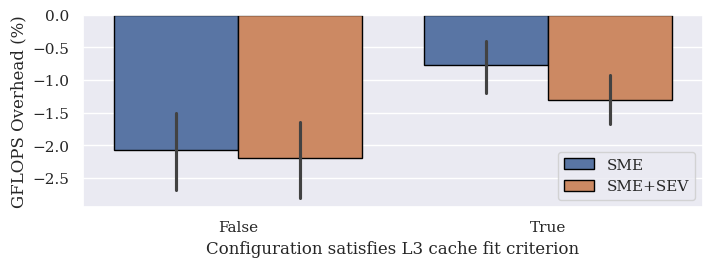

In [173]:
plt.figure(figsize=(8, 2.5))
sns.barplot(overhead_df, x="L3_fit", y="SpMV_GFLOPS_pct", hue="Mode", edgecolor="black")
plt.legend(title=None)
plt.xlabel("Configuration satisfies L3 cache fit criterion")
plt.ylabel("GFLOPS Overhead (%)")
plt.savefig("images/overhead_by_L3_fit_SpMV_GFLOPS_pct.pdf", bbox_inches='tight')
print(overhead_df.groupby(["L3_fit", "Mode"])["SpMV_GFLOPS_pct"].mean())

In [ ]:
#How many configs are L3 fit?
print("L3 fit configs:", df["L3_fit"].sum(), "/", len(df))

L3 fit configs: 168 / 480


## Input matrix effects

→ MB:
Mode    SME  SME+SEV
MB                  
10.0   -0.9     -1.0
70.0   -0.7     -1.2
150.0  -1.3     -1.9
500.0  -2.3     -2.4
3000.0 -2.9     -3.0
------------------------------------------------------------
→ Randomness:
Mode        SME  SME+SEV
Randomness              
0.0        -1.0     -1.2
1.0        -2.2     -2.6
------------------------------------------------------------


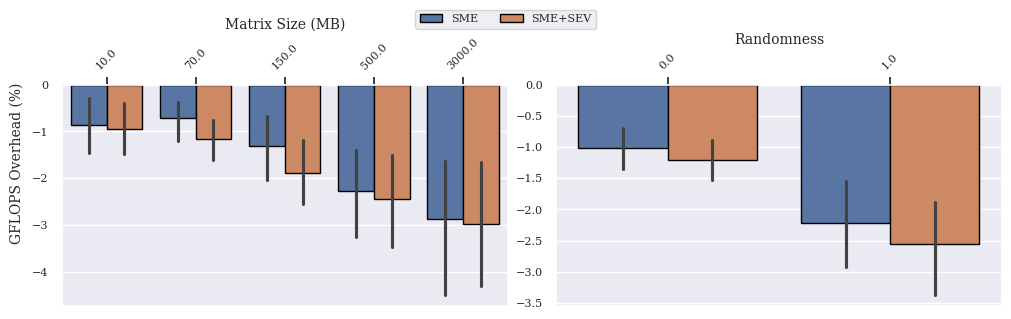

In [18]:
plot_metric_by_dimensions(overhead_df, "SpMV_GFLOPS_pct", "GFLOPS Overhead (%)", top=True, figname="overhead_by_mb_randomness.pdf", top_metrics=["MB","Randomness"], bottom_metrics=None)


Displayed bar values for L3_fit:
 L3_fit    Mode  Impact
  False     SME    -2.0
  False SME+SEV    -2.2
   True     SME     0.2
   True SME+SEV     0.1

Displayed bar values for VM_NUMA:
   VM_NUMA    Mode  Impact
    strict     SME    -1.0
    strict SME+SEV    -1.1
interleave     SME    -1.4
interleave SME+SEV    -1.7


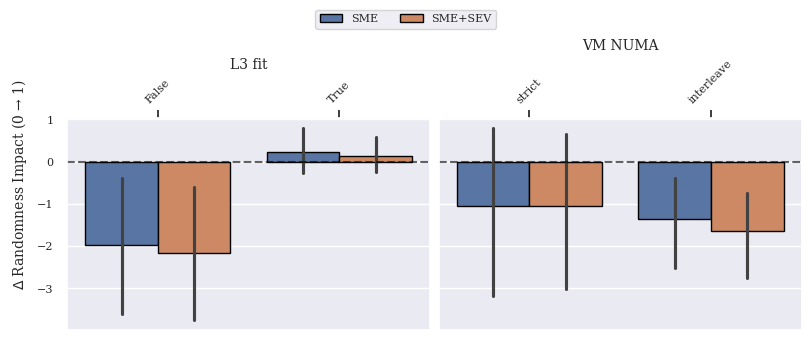

In [19]:
#matrix pattern impact
# Global configuration: (Baseline/Low State, Stressed/High State)
# Order matters: Impact = High - Low
DIM_CONFIG = {
    'Randomness': (0, 1),
    'VM_NUMA': ('strict', 'interleave'),
    'L3_fit': (True, False),
}

def get_impact_df(df, target_dim):
    """
    Calculates pairwise delta for target_dim using DIM_CONFIG.
    For MB/Cores, it defaults to (min, max).
    """
    all_dims = ['Mode', 'MB', 'Cores', 'VM_NUMA', 'Randomness', 'L3_fit']
    index_cols = [c for c in all_dims if c != target_dim]
    
    # Get comparison values
    if target_dim in DIM_CONFIG:
        low_val, high_val = DIM_CONFIG[target_dim]
    else:
        low_val, high_val = df[target_dim].min(), df[target_dim].max()
    
    # Pivot and calculate Delta
    pivot = df.pivot_table(
        index=index_cols, 
        columns=target_dim, 
        values='SpMV_GFLOPS_pct'
    ).reset_index()
    
    # Impact = 'Stressed' minus 'Baseline'
    pivot['Impact'] = pivot[high_val] - pivot[low_val]
    
    # Store metadata for the plotter to use in titles
    pivot.attrs['comparison'] = f"{low_val} → {high_val}"
    pivot.attrs['target'] = target_dim
    return pivot

def plot_impact_comparison(impact_df, compare_features, print_bar_values=True):
    """
    Plots the impact with automated, descriptive titles.
    Also prints the displayed bar values (mean Impact per x/hue).
    """
    target = impact_df.attrs.get('target', 'Dimension')
    comp_str = impact_df.attrs.get('comparison', '')

    # Explicit plotting order for categorical dimensions
    order_map = {
        "VM_NUMA": ["strict", "interleave"],
    }

    fig, axes = plt.subplots(1, len(compare_features), figsize=(8, 3), constrained_layout=True, sharey=True)
    if len(compare_features) == 1:
        axes = [axes]

    fig.supylabel(f"$\\Delta$ {target} Impact ({comp_str})", fontsize=10)

    for i, feat in enumerate(compare_features):
        ax = axes[i]
        x_order = [v for v in order_map.get(feat, []) if v in impact_df[feat].dropna().unique()] or None

        if print_bar_values:
            bar_vals = (
                impact_df.groupby([feat, "Mode"], as_index=False)["Impact"]
                .mean()
                .round(1)
            )
            if x_order is not None:
                bar_vals[feat] = pd.Categorical(bar_vals[feat], categories=x_order, ordered=True)
            bar_vals = bar_vals.sort_values([feat, "Mode"])

            print(f"\nDisplayed bar values for {feat}:")
            print(bar_vals.to_string(index=False))

        sns.barplot(
            data=impact_df,
            x=feat,
            y="Impact",
            hue="Mode",
            order=x_order,
            edgecolor="black",
            ax=ax,
        )

        ax.axhline(0, linestyle="--", color="black", alpha=0.6)
        ax.set_title(feat.replace("_", " "), fontsize=10)
        ax.set_ylabel("")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=45, labelsize=8)
        ax.tick_params(axis="y", labelsize=8)
        ax.xaxis.set_ticks_position("top")
        ax.xaxis.set_label_position("top")
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.1), fontsize=8)

    fig.savefig("images/randomness_impact.pdf", bbox_inches="tight")
    plt.show()

rand_df = get_impact_df(overhead_df, 'Randomness')
plot_impact_comparison(rand_df, ["L3_fit", "VM_NUMA"])


## Hardware Counter

Mode          SME  SME+SEV
Metric                    
Cache Misses  6.6      3.5
Cycles        1.8      1.8
Instructions -0.1     -0.1
dTLB Misses  -0.1     42.4

------------------------------------------------------------


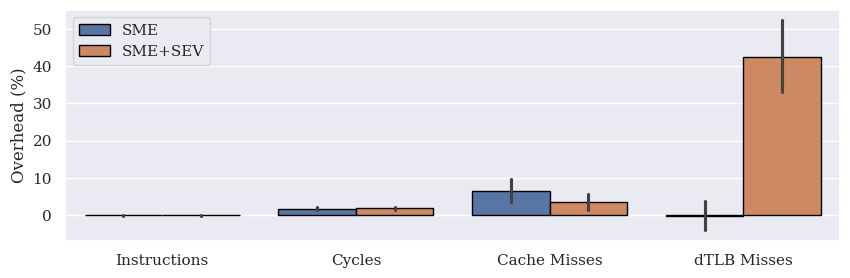

In [20]:
plot_df = overhead_df.melt(
    id_vars=["Mode"],
    value_vars=["Perf_Instructions_pct", "Perf_Cycles_pct", "Perf_CacheMisses_pct", "Perf_dTLBMisses_pct"],
    var_name="Metric",
    value_name="Overhead_pct"
)

plot_df["Metric"] = plot_df["Metric"].map({
    "Perf_Instructions_pct": "Instructions",
    "Perf_Cycles_pct": "Cycles",
    "Perf_CacheMisses_pct": "Cache Misses",
    "Perf_dTLBMisses_pct": "dTLB Misses",
})

plt.figure(figsize=(10, 3))
sns.barplot(data=plot_df, x="Metric", y="Overhead_pct", errorbar=('ci', 95), edgecolor='black', hue="Mode")
plt.legend(title=None)
plt.xlabel("")
plt.ylabel("Overhead (%)")
plt.savefig("images/overhead_by_perf_metric.pdf", bbox_inches='tight')

summary = (plot_df.groupby(['Metric', 'Mode'])['Overhead_pct']
           .mean()
           .round(2)
           .unstack())

print(summary.to_string(float_format="{:.1f}".format))
print("\n" + "-" * 60)

Mode            Native         SME     SME+SEV
Randomness                                    
0.0          164464902   165800330   165070056
1.0        47727044430 47556146509 47659196643
Mode        SME  SME+SEV
Randomness              
0.0        12.1      6.5
1.0         1.1      0.5


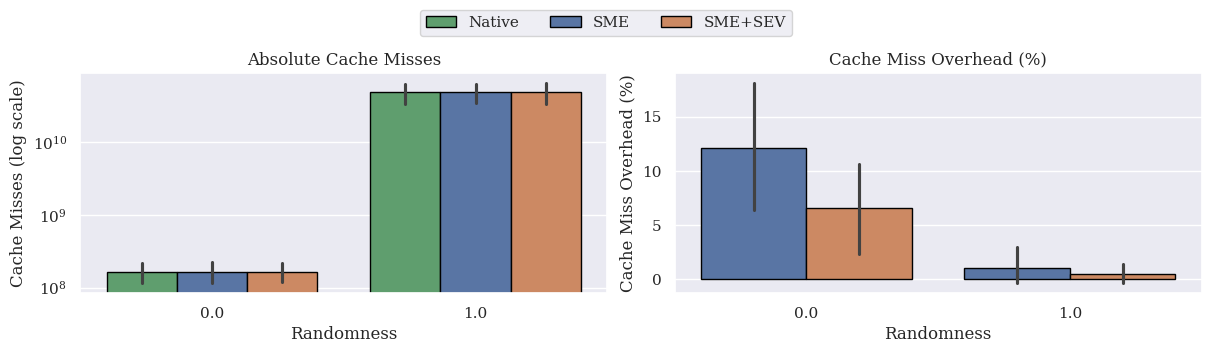

In [21]:
base = sns.color_palette("deep", 3)
palette = {
    "Native": base[2],  
    "SME": base[0],     
    "SME+SEV": base[1] 
}

fig, ax = plt.subplots(ncols=2, figsize=(12, 3), constrained_layout=True)

sns.barplot(data=df, x="Randomness", y="Perf_CacheMisses", hue="Mode", palette=palette, errorbar=('ci', 95), edgecolor='black', ax=ax[0])
ax[0].set_yscale("log")
ax[0].set_title("Absolute Cache Misses")
ax[0].set_ylabel("Cache Misses (log scale)")
ax[0].get_legend().remove()


sns.barplot(data=overhead_df, x="Randomness", y="Perf_CacheMisses_pct", hue="Mode", palette=palette, errorbar=('ci', 95), edgecolor='black', ax=ax[1])
ax[1].set_title("Cache Miss Overhead (%)")
ax[1].set_ylabel("Cache Miss Overhead (%)")
ax[1].get_legend().remove()

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=3)

plt.savefig("images/cache_misses_absolute_and_overhead_by_randomness.pdf", bbox_inches='tight')

print(df.groupby(['Randomness', 'Mode'])['Perf_CacheMisses'].mean().unstack().to_string(float_format="{:.0f}".format))
print(overhead_df.groupby(['Randomness', 'Mode'])['Perf_CacheMisses_pct'].mean().unstack().to_string(float_format="{:.1f}".format))

## IO Analysis

Mode     MB    
SME      10.0       3.762282
         70.0       6.541224
         150.0      7.040207
         500.0      7.128418
         3000.0     8.245188
SME+SEV  10.0       4.113318
         70.0       7.937879
         150.0      8.795880
         500.0      9.552155
         3000.0    10.576922
Name: IO_Time_pct, dtype: float64

Average absolute deviation between randomness across configurations: 1.135%


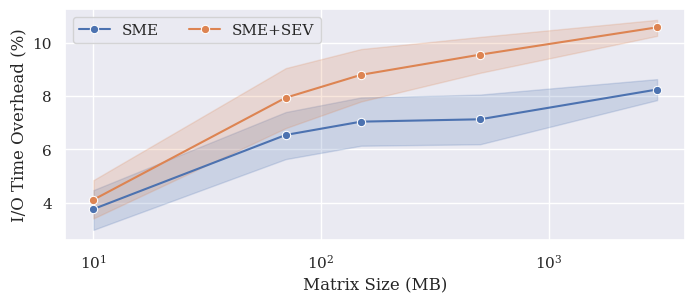

In [22]:
plt.figure(figsize=(8, 3))
sns.lineplot(data=overhead_df, x="MB", y="IO_Time_pct", marker="o", hue="Mode")
plt.xscale("log")
plt.xlabel("Matrix Size (MB)")
plt.ylabel("I/O Time Overhead (%)")
plt.legend(ncol=2)
plt.savefig("images/IO_Time_Overhead_by_MB.pdf", bbox_inches='tight')
print(overhead_df.groupby(["Mode", "MB"])["IO_Time_pct"].mean())
cfg_cols = ["Mode", "MB", "Cores", "Process_NUMA", "VM_NUMA"]

io_rand_cmp = (
	overhead_df
	.pivot_table(
		index=cfg_cols,
		columns="Randomness",
		values="IO_Time_pct",
		aggfunc="mean"
	)
	.dropna(subset=[0.0, 1.0])
	.reset_index()
)

io_rand_cmp["IO_Time_Deviation_pct"] = io_rand_cmp[1.0] - io_rand_cmp[0.0]
io_rand_cmp["Abs_IO_Time_Deviation_pct"] = io_rand_cmp["IO_Time_Deviation_pct"].abs()

print(f"\nAverage absolute deviation between randomness across configurations: {io_rand_cmp['Abs_IO_Time_Deviation_pct'].mean():.3f}%")
diff = io_rand_cmp["IO_Time_Deviation_pct"]

## Worst configurations

In [23]:
def top_10_percent_per_mode(df, value_col):
    return df[
        df.groupby("Mode")[value_col]
          .transform(lambda x: x.rank(method="first", ascending=True)
                               <= int(len(x) * 0.1))
    ]

cutoffs = overhead_df.groupby("Mode")["SpMV_GFLOPS_pct"].apply(
    lambda x: x.nsmallest(int(len(x) * 0.1)).max()
)

print(cutoffs)

top_configs = top_10_percent_per_mode(overhead_df, "SpMV_GFLOPS_pct")

result_df = (
    top_configs
    .melt(id_vars=["Mode"], value_vars=config_cols,
          var_name="Metric", value_name="Value")
    .groupby(["Mode", "Metric", "Value"])
    .size()
    .reset_index(name="Count")
)

result_df["Representation"] = (
    result_df.groupby(["Mode", "Metric"])["Count"]
    .transform(lambda x: 100 * x / x.sum())
)

result_df = result_df.sort_values(
    ["Mode", "Metric", "Representation"],
    ascending=[True, True, False]
)

n_levels = overhead_df[config_cols].nunique()

result_df["Expected"] = result_df["Metric"].map(lambda m: 1 / n_levels[m])

result_df["Lift"] = (
    result_df["Representation"] / 100
) / result_df["Expected"]

result_df

Mode
SME       -4.723854
SME+SEV   -4.960052
Name: SpMV_GFLOPS_pct, dtype: float64


,Mode,Metric,Value,Count,Representation,Expected,Lift
0,SME,Cores,1.0,10,62.50,0.25,2.5000
1,SME,Cores,24.0,3,18.75,0.25,0.7500
2,SME,Cores,48.0,3,18.75,0.25,0.7500
3,SME,L3_fit,0.0,14,87.50,0.50,1.7500
4,SME,L3_fit,1.0,2,12.50,0.50,0.2500
9,SME,MB,3000.0,6,37.50,0.20,1.8750
8,SME,MB,500.0,5,31.25,0.20,1.5625
7,SME,MB,150.0,3,18.75,0.20,0.9375
5,SME,MB,10.0,1,6.25,0.20,0.3125
6,SME,MB,70.0,1,6.25,0.20,0.3125
